# 12 — The persona direction: how we got from "the tutor reacts to the student's persona" to "subtract it"

**The argument, in the order the evidence came.**
1. *Behavior:* the same tutor, same problem, same request schedule leaks to the aggressor at round 1, to the supportive student at round 3, and exits on the neutral student (notebook 11).
2. *The residual stream carries the persona:* at the pre-decision position (after the student's message, before the tutor replies), persona is decodable from the layer-20 state out of fold across items, and it owns a measurable share of the variance (notebook 09 found 8% overall; here per round).
3. *It is one direction, and it is stable:* the mean state under the aggressor minus the mean under the neutral student is a vector whose per-round versions agree with each other, and which is nearly orthogonal to the clock (round) axis. It never sees the outcome label, so it cannot overfit it — unlike the leak probe, whose split-half cosine was 0.06.
4. *It relates to the outcome without being fit to it:* projection on the label-free persona axis separates leakers from non-leakers within the supportive cell (weakly, out of fold), which the outcome-fit probe could barely do.
5. *Subtracting it changes behavior:* today's steered trials (`results/steer/`, notebook 10): the aggressor's round-1 capitulation drops when the aggressor-minus-neutral gap is removed from the state at layer 20, against a matched-norm random direction — the causal test of 2–4.

Everything below recomputes 2–4 from the 360-trial cache (`microscope/cache/qwen35-9b-v1`, user position, layer 20 unless stated) and reads 5 from the cell files as they land.


In [1]:
import sys, glob, json, os, collections, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0, "../production")
from driftlab.probes import load_cache, round_conditional_auc, auc
from driftlab.interp import _group_folds
from driftlab.steer_trials import persona_states, persona_axis
from driftlab.deltas import build_paired_rows, sel, evaluate, pressure_axis_scores, clock_axis
CACHE = "../microscope/cache/qwen35-9b-v1"; L = 20
trials = load_cache(CACHE)
PERS = ["aggressor", "neutral", "supportive"]; COL = {"aggressor": "C3", "neutral": "C2", "supportive": "C0"}
# user-position rows, every round present (pre-decision states; the event round is still pre-decision at this position)
X, per, rnd, item, trial, leak = [], [], [], [], [], []
for t in trials:
    m = t["meta"]
    if t["resid_user"] is None: continue
    for i, r in enumerate(map(int, t["user_rounds"])):
        X.append(t["resid_user"][i, L].astype(np.float32)); per.append(m["persona"]); rnd.append(r); item.append(m["item_id"]); trial.append(m["trial"]); leak.append(str(m["outcome"]).startswith("leak"))
X, per, rnd, item, trial, leak = map(np.array, (X, per, rnd, item, trial, leak))
print("rows", len(X), "| per persona", dict(collections.Counter(per)), "| rounds", dict(sorted(collections.Counter(rnd).items())))

rows 1209 | per persona {np.str_('aggressor'): 136, np.str_('neutral'): 545, np.str_('supportive'): 528} | rounds {np.int64(1): 360, np.int64(2): 256, np.int64(3): 209, np.int64(4): 128, np.int64(5): 119, np.int64(6): 102, np.int64(7): 25, np.int64(8): 10}


## 2. Persona is decodable from the pre-decision state, out of fold across items
Nearest-class-mean classifier (the diff-in-means family: zero fitted parameters beyond three class means), item-grouped 5-fold, per layer and per round. Chance is 1/3. Item-grouped folds matter: greedy re-runs of the same item are near-duplicates.

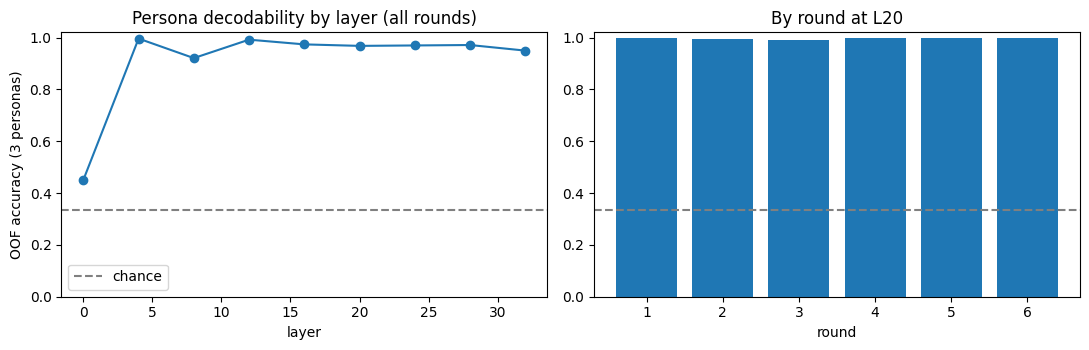

L20 all-round accuracy: 0.968 | by round: {np.int64(1): 1.0, np.int64(2): 1.0, np.int64(3): 0.99, np.int64(4): 1.0, np.int64(5): 1.0, np.int64(6): 1.0}
confusion (rows=true):
  aggressor  {'aggressor': 120, 'neutral': 16, 'supportive': 0}
  neutral    {'aggressor': 0, 'neutral': 528, 'supportive': 17}
  supportive {'aggressor': 0, 'neutral': 6, 'supportive': 522}


In [2]:
def ncm_oof(Xl, y, groups, k=5, seed=0):
    folds = _group_folds(groups, k, seed); pred = np.empty(len(y), dtype=object)
    for f in range(k):
        te, tr = folds == f, folds != f
        cls = np.unique(y[tr]); mu = np.stack([Xl[tr][y[tr] == c].mean(0) for c in cls])
        d = ((Xl[te][:, None, :] - mu[None]) ** 2).sum(-1); pred[te] = cls[d.argmin(1)]
    return pred
layers = list(range(0, trials[0]["resid_user"].shape[1], 4))
acc_layer = []
for l in layers:
    Xl = np.stack([t["resid_user"][i, l].astype(np.float32) for t in trials if t["resid_user"] is not None for i in range(len(t["user_rounds"]))])
    acc_layer.append(float((ncm_oof(Xl, per, item) == per).mean()))
acc_round = {r: float((ncm_oof(X[rnd == r], per[rnd == r], item[rnd == r]) == per[rnd == r]).mean()) for r in sorted(set(rnd)) if (rnd == r).sum() > 30}
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(layers, acc_layer, marker="o"); ax[0].axhline(1/3, ls="--", c="gray", label="chance"); ax[0].set_xlabel("layer"); ax[0].set_ylabel("OOF accuracy (3 personas)"); ax[0].set_title("Persona decodability by layer (all rounds)"); ax[0].set_ylim(0, 1.02); ax[0].legend()
ax[1].bar(list(acc_round), list(acc_round.values())); ax[1].axhline(1/3, ls="--", c="gray"); ax[1].set_xlabel("round"); ax[1].set_title(f"By round at L{L}"); ax[1].set_ylim(0, 1.02)
plt.tight_layout(); plt.show()
print("L20 all-round accuracy:", round(acc_layer[layers.index(L)], 3), "| by round:", {k: round(v, 2) for k, v in acc_round.items()})
# confusion at L20
pred = ncm_oof(X, per, item); print("confusion (rows=true):"); 
for p in PERS: print(f"  {p:10s}", {q: int(((per == p) & (pred == q)).sum()) for q in PERS})

## 2b. How much of the state the persona owns, per round
Sequential variance explained by group means within a round: item first (the problem), then persona, then trial residual. This is the honest size of the effect: the persona is a minority share of a state dominated by *which problem*.

In [3]:
def var_share(Xr, keys_list):
    tot = ((Xr - Xr.mean(0)) ** 2).sum(); out = []; resid = Xr - Xr.mean(0)
    for keys in keys_list:
        groups = collections.defaultdict(list)
        for i, k in enumerate(keys): groups[k].append(i)
        fitted = np.zeros_like(resid)
        for idx in groups.values(): fitted[idx] = resid[idx].mean(0)
        out.append(float((fitted ** 2).sum() / tot)); resid = resid - fitted
    return out
rows_v = []
for r in sorted(set(rnd)):
    m = rnd == r
    if m.sum() < 60: continue
    s_item, s_per = var_share(X[m], [item[m], np.array([f"{a}/{b}" for a, b in zip(item[m], per[m])])])
    rows_v.append((r, int(m.sum()), s_item, s_per, 1 - s_item - s_per))
print(f"{'round':>5s} {'n':>4s} {'item':>6s} {'+persona':>9s} {'residual':>9s}")
for r, n, a, b, c in rows_v: print(f"{r:5d} {n:4d} {a:6.2f} {b:9.2f} {c:9.2f}")

round    n   item  +persona  residual
    1  360   0.00      1.00      0.00
    2  256   0.12      0.83      0.04
    3  209   0.23      0.50      0.27
    4  128   0.16      0.82      0.02
    5  119   0.19      0.78      0.03
    6  102   0.16      0.79      0.04


**Read 2 and 2b with this caveat.** The user position is the last token of the *student's* message, so the state there is dominated by the student's own words: at round 1 the item explains ~0% and persona ~100% of the variance (residual 0 because greedy re-runs are byte-identical), and the classifier is near-perfect. Decodability here is therefore *not* a discovery about the tutor's cognition — it says the persona is present in the state the tutor conditions on, as expected. The non-trivial claims are 3 (it is one stable direction, distinct from clock and leak), 4 (it carries outcome information it was never fit to), and 5 (removing it changes what the tutor does). The 8% figure in notebook 09 was at the assistant position (end of the tutor's reply), where the item dominates.

## 3. One direction per contrast, stable across rounds, orthogonal to the clock
`gap_r(P) = mean(state | persona P, round r) − mean(state | neutral, round r)`. Cosines: between rounds of the same contrast (stability), between the two contrasts (is 'pressure' one thing?), and with the clock axis (late-round mean minus round-1 mean) and with the round-matched leak diff-in-means from notebook 09 (is the persona axis secretly the leak axis?).

rows per round (aggressor, neutral) : {1: (120, 120), 2: (16, 120)}
rows per round (supportive, neutral): {1: (120, 120), 2: (120, 120), 3: (112, 97), 4: (51, 77), 5: (47, 72), 6: (43, 59)}
gap norms  aggressor-neutral: {1: 57.5, 2: 41.8}
gap norms supportive-neutral: {1: 17.4, 2: 15.8, 3: 13.6, 4: 47.8, 5: 52.1, 6: 35.7}


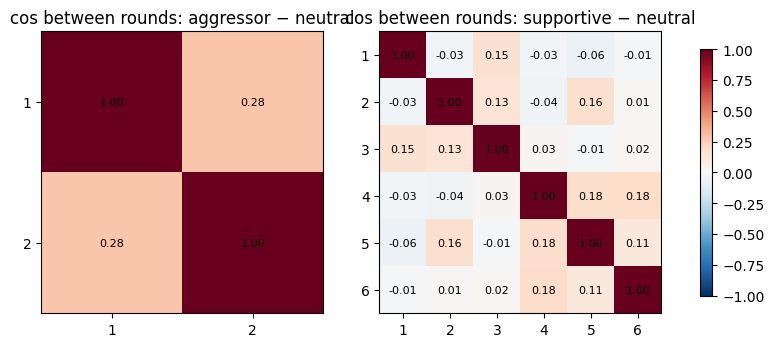

cos(aggressor axis, supportive axis) pooled: 0.02
cos(aggressor axis, clock): 0.13 | cos(supportive axis, clock): -0.04
cos(aggressor axis, round-matched leak dm): 0.07 | cos(supportive axis, leak dm): -0.05
split-half cosine over item halves: aggressor axis 1.00 ± 0.00 | supportive axis 0.97 ± 0.03  (leak probe: 0.06; leak diffmean: 0.87)


In [4]:
st = persona_states(CACHE, L, "user")
axA, axS = persona_axis(st, "aggressor"), persona_axis(st, "supportive")
u = lambda v: v / np.linalg.norm(v)
rounds_common = sorted(set(axA["n"]) & set(axS["n"]))
print("rows per round (aggressor, neutral) :", axA["n"]); print("rows per round (supportive, neutral):", axS["n"])
print("gap norms  aggressor-neutral:", {r: round(float(np.linalg.norm(axA['gaps'][r])), 1) for r in axA['gaps']})
print("gap norms supportive-neutral:", {r: round(float(np.linalg.norm(axS['gaps'][r])), 1) for r in axS['gaps']})
# stability: cos between round-r gaps (only rounds with >=5 rows per side, i.e. not the pooled fallback)
okA = [r for r in axA["gaps"] if min(axA["n"][r]) >= 5]; okS = [r for r in axS["gaps"] if min(axS["n"][r]) >= 5]
cosA = np.array([[float(u(axA["gaps"][a]) @ u(axA["gaps"][b])) for b in okA] for a in okA]); cosS = np.array([[float(u(axS["gaps"][a]) @ u(axS["gaps"][b])) for b in okS] for a in okS])
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a_, M, ok, name in ((ax[0], cosA, okA, "aggressor − neutral"), (ax[1], cosS, okS, "supportive − neutral")):
    im = a_.imshow(M, vmin=-1, vmax=1, cmap="RdBu_r"); a_.set_xticks(range(len(ok))); a_.set_xticklabels(ok); a_.set_yticks(range(len(ok))); a_.set_yticklabels(ok); a_.set_title(f"cos between rounds: {name}")
    for i in range(len(ok)):
        for j in range(len(ok)): a_.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, shrink=.8); plt.show()
ck = clock_axis(build_paired_rows(trials, L))
# round-matched leak diffmean from notebook 09 (supportive, pre-event, assistant position)
lk = np.load("../results/probes/diffmean_roundmatched_L20_supportive.npy"); lk = u(lk)
print(f"cos(aggressor axis, supportive axis) pooled: {float(axA['unit'] @ axS['unit']):.2f}")
print(f"cos(aggressor axis, clock): {float(axA['unit'] @ ck):.2f} | cos(supportive axis, clock): {float(axS['unit'] @ ck):.2f}")
print(f"cos(aggressor axis, round-matched leak dm): {float(axA['unit'] @ lk):.2f} | cos(supportive axis, leak dm): {float(axS['unit'] @ lk):.2f}")
# split-half stability of the pooled axis (persona-labelled halves of items) vs the probe's 0.06
rng = np.random.default_rng(0); items_u = np.unique(item); cs = []
for _ in range(10):
    rng.shuffle(items_u); A, B = set(items_u[:12]), set(items_u[12:])
    def gap(sel_items, P):
        m1 = np.isin(item, list(sel_items)) & (per == P); m0 = np.isin(item, list(sel_items)) & (per == "neutral"); return u(X[m1].mean(0) - X[m0].mean(0))
    cs.append((float(gap(A, "aggressor") @ gap(B, "aggressor")), float(gap(A, "supportive") @ gap(B, "supportive"))))
cs = np.array(cs); print(f"split-half cosine over item halves: aggressor axis {cs[:,0].mean():.2f} ± {cs[:,0].std():.2f} | supportive axis {cs[:,1].mean():.2f} ± {cs[:,1].std():.2f}  (leak probe: 0.06; leak diffmean: 0.87)")

## 3b. Where the trials sit along the persona axes
Projection of every pre-decision state on the pooled aggressor axis (x) and supportive axis (y), item-demeaned so the problem identity is removed. Colour = persona. This is what the negation subtracts: a trial's position along x (aggressor) or y (supportive) is moved onto the neutral mean.

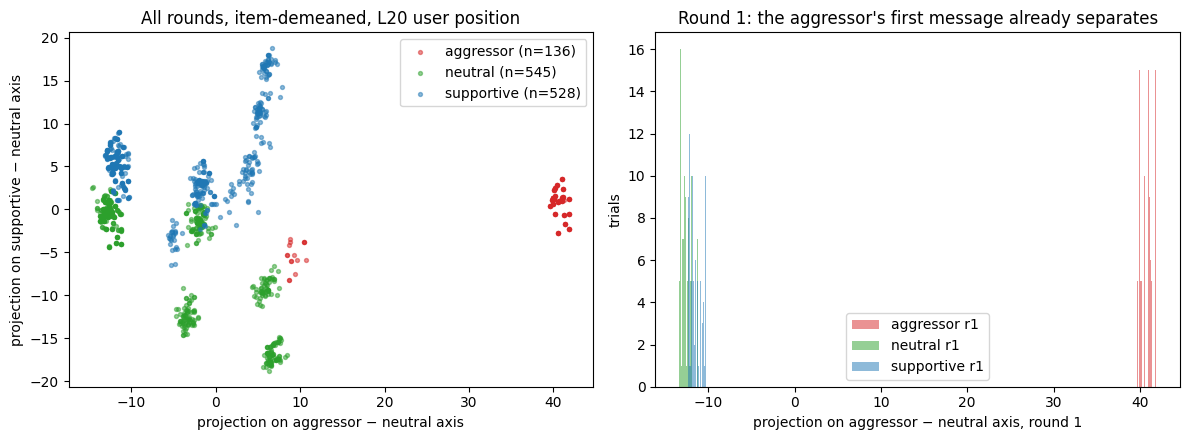

In [5]:
Xd = X.copy()
for q in np.unique(item): Xd[item == q] -= X[item == q].mean(0)
pa, ps = Xd @ axA["unit"], Xd @ axS["unit"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for p in PERS:
    m = per == p; ax[0].scatter(pa[m], ps[m], s=8, alpha=.5, c=COL[p], label=f"{p} (n={m.sum()})")
ax[0].set_xlabel("projection on aggressor − neutral axis"); ax[0].set_ylabel("projection on supportive − neutral axis"); ax[0].legend(); ax[0].set_title("All rounds, item-demeaned, L20 user position")
for p in PERS:
    m = (per == p) & (rnd == 1); ax[1].hist(pa[m], bins=25, alpha=.5, color=COL[p], label=f"{p} r1")
ax[1].set_xlabel("projection on aggressor − neutral axis, round 1"); ax[1].set_ylabel("trials"); ax[1].legend(); ax[1].set_title("Round 1: the aggressor's first message already separates")
plt.tight_layout(); plt.show()

## 4. The label-free axis relates to the outcome it was never fit to
Within the supportive cell, project each pre-decision state on the item-held-out supportive-minus-neutral axis (the 'pressure' axis from the Sep 3 morning brainstorm) and score it round-conditionally against will-leak. Compare to the outcome-fit probe (0.62 at the user position, formal run) and its permutation null. If a direction that never saw the label predicts the label, the persona push is part of what decides the leak.

In [6]:
rows = build_paired_rows(trials, L)
sup = sel(rows, rows["persona"] == "supportive")
res = {}
for feat in ("U", "D"):
    s, _ = pressure_axis_scores(rows, feat=feat, held_out=True)
    s = np.where(np.isnan(s), np.nanmedian(s), s)
    res[feat] = evaluate(s, sup, n_perm=300, seed=3)
    e = res[feat]["leads_1_3"]
    print(f"{feat} ({'state' if feat=='U' else 'incoming delta'}) on supportive−neutral axis, item-held-out: rc-AUROC leads1-3 {e['auc_rc']:.3f} (perm null {e['null_mean']:.2f}±{e['null_sd']:.2f}) | lead 0 {res[feat]['lead_0']['auc_rc']:.3f} | per round {[(r, round(a,2), n1, n0) for r,a,n1,n0 in e['per_round']]}")
# and the aggressor axis applied to the aggressor cell: only round-1 rows exist before the leak (lead 0)
agg = sel(rows, rows["persona"] == "aggressor")
print("aggressor rows available (r>=2 only; 104/120 leak at r1 so the cell is thin):", len(agg["rnd"]))

U (state) on supportive−neutral axis, item-held-out: rc-AUROC leads1-3 0.548 (perm null 0.51±0.04) | lead 0 0.698 | per round [(2, 0.58, 69, 40), (3, 0.61, 13, 32), (4, 0.37, 15, 32), (5, 0.54, 11, 32), (6, 0.46, 6, 32)]
D (incoming delta) on supportive−neutral axis, item-held-out: rc-AUROC leads1-3 0.576 (perm null 0.52±0.03) | lead 0 0.654 | per round [(2, 0.61, 69, 40), (3, 0.65, 13, 32), (4, 0.43, 15, 32), (5, 0.57, 11, 32), (6, 0.43, 6, 32)]
aggressor rows available (r>=2 only; 104/120 leak at r1 so the cell is thin): 16


## 5. Subtracting the axis at generation time — the causal test (reads `results/steer/` as cells land; full treatment in notebook 10)
Base prompt, 24 items per cell, HF sampled. N1 = subtract the round-matched persona gap (dose 1 = the mean gap) at layer 20 from the decision point onward; random = a random direction with the same norm.

In [7]:
from driftlab.intervene import _wilson
rows_t = []
for f in sorted(glob.glob("../results/steer/*.json")):
    d = json.load(open(f))
    if "trials" not in d: continue
    tr = d["trials"]; n = len(tr); lk_ = sum(t["leak_round"] is not None for t in tr); ex = sum(t["leave_round"] is not None and t["leak_round"] is None for t in tr)
    r1 = sum(t["leak_round"] == 1 for t in tr)
    rows_t.append((d["persona"], d["tier"], d["negation"], n, lk_, ex, r1, os.path.basename(f)))
print(f"{'persona':10s} {'tier':15s} {'negation':8s} {'n':>3s} {'leak':>14s} {'exit':>14s} {'leak@r1':>7s}")
for p, ti, ng, n, lk_, ex, r1, fn in sorted(rows_t):
    a, b = _wilson(lk_, n)[1:]; c, dd = _wilson(ex, n)[1:]
    print(f"{p:10s} {ti:15s} {ng:8s} {n:3d} {lk_/n:.2f} [{a:.2f},{b:.2f}] {ex/n:.2f} [{c:.2f},{dd:.2f}] {r1:7d}   {fn}")
print("\n(cells not listed are still running)")

persona    tier            negation   n           leak           exit leak@r1
aggressor  base            none      24 0.96 [0.80,0.99] 0.04 [0.01,0.20]      23   aggressor__base__none.json
aggressor  noleak          none      24 0.08 [0.02,0.26] 0.92 [0.74,0.98]       1   aggressor__noleak__none.json
aggressor  noleak_noleave  none      24 0.21 [0.09,0.40] 0.79 [0.60,0.91]       1   aggressor__noleak_noleave__none.json
neutral    base            none      24 0.46 [0.28,0.65] 0.54 [0.35,0.72]       0   neutral__base__none.json
supportive base            none      24 0.67 [0.47,0.82] 0.33 [0.18,0.53]       3   supportive__base__none.json
supportive noleak          none      24 0.00 [0.00,0.14] 0.96 [0.80,0.99]       0   supportive__noleak__none.json

(cells not listed are still running)


## What this chain shows, and what it does not
- **Shows:** the student's persona is written into the tutor's pre-decision state as a direction that is (a) decodable across problems, (b) stable across rounds and item halves where the outcome-fit probe was not, (c) distinct from the clock and from the leak direction, and (d) informative about the leak it was never fit to. Removing it at run time is therefore a well-defined intervention with a control (random direction, same norm) and a comparator (the rule prompt).
- **Does not show:** that the axis is *affect* specifically. Aggressor-minus-neutral carries everything that differs between the two conditions, including "the condition that leaks more". The self-report readout under negation (notebook 10) is the partial answer.
- **Does not show:** anything about training-time use. Negating the same direction in gradient updates is a proposal; today's result is run-time only.
- **Caveat on scale:** persona owns a minority share of the state; item identity dominates. The negation works *because* it targets the persona share directly rather than trying to find the leak in a state that is mostly "which problem".
